In [1]:
from google.colab import drive
# Load the data set and unzip it.
drive.mount('/content/drive')
import zipfile
zip_path = '/content/drive/MyDrive/Snake_FeaturedDataset.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')
print("Dataset extracted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully!


In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. DATA LOADING & PREPROCESSING

# Load features
features_path = "/content"
X = np.load(os.path.join(features_path, "selected_features.npy"))
y = np.load(os.path.join(features_path, "labels.npy"))

print(f"• Features: {X.shape}")
print(f"• Labels: {y.shape}")
print(f"• Classes: {np.unique(y)}")


• Features: (33117, 500)
• Labels: (33117,)
• Classes: [0. 1.]


In [3]:
# Apply 3 DIFFERENT pre-processing methods (different from Decision Tree)

preprocessing_methods = {
    'StandardScaler': StandardScaler(),
    'PowerTransformer': PowerTransformer(method='yeo-johnson'),
    'QuantileTransformer_Normal': QuantileTransformer(output_distribution='normal', random_state=42)
}

preprocessed_data = {}
for preproc_name, preprocessor in preprocessing_methods.items():
    print(f"   Applying {preproc_name}...")
    preprocessed_data[preproc_name] = preprocessor.fit_transform(X)

print(" Pre-processing completed")

   Applying StandardScaler...
   Applying PowerTransformer...
   Applying QuantileTransformer_Normal...
 Pre-processing completed


In [5]:
# 2. MULTIPLE SVM VARIETIES WITH HYPERPARAMETER TUNING

svm_varieties = {
    'LinearSVC_Fast': {
        'model': LinearSVC(random_state=42, dual=False, max_iter=1000),
        'param_grid': {
            'C': [0.01, 0.1, 1, 10],
            'class_weight': [None, 'balanced']
        }
    },
    'SVC_Linear': {
        'model': SVC(kernel='linear', random_state=42, probability=True),
        'param_grid': {
            'C': [0.1, 1, 10],
            'class_weight': [None, 'balanced']
        }
    },
    'SVC_RBF': {
        'model': SVC(kernel='rbf', random_state=42, probability=True),
        'param_grid': {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto'],
            'class_weight': [None, 'balanced']
        }
    },
    'SVC_Poly': {
        'model': SVC(kernel='poly', random_state=42, probability=True),
        'param_grid': {
            'C': [0.1, 1],
            'degree': [2, 3],
            'class_weight': [None, 'balanced']
        }
    }
}


In [6]:
def comprehensive_svm_evaluation(preprocessed_data, svm_varieties):

    results = []
    total_combinations = len(preprocessed_data) * len(svm_varieties)
    current_combination = 0

    print(f"\n COMPREHENSIVE EVALUATION: {total_combinations} COMBINATIONS...")

    for preproc_name, X_processed in preprocessed_data.items():
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X_processed, y, test_size=0.2, random_state=42, stratify=y
        )

        # Optimal subsampling: 800 samples
        if X_train.shape[0] > 800:
            X_train_800, _, y_train_800, _ = train_test_split(
                X_train, y_train, train_size=800, random_state=42, stratify=y_train
            )
            print(f"\n Using 800 samples for {preproc_name}: {X_train_800.shape}")
            X_train_final, y_train_final = X_train_800, y_train_800
        else:
            X_train_final, y_train_final = X_train, y_train

        for variety_name, variety_config in svm_varieties.items():
            current_combination += 1
            print(f"\n [{current_combination}/{total_combinations}] {variety_name} + {preproc_name}")

            start_time = time.time()

            # Hyperparameter tuning with RandomizedSearchCV
            quick_search = RandomizedSearchCV(
                variety_config['model'],
                variety_config['param_grid'],
                n_iter=3,  # Test 3 random combinations
                cv=2,      # 2-fold CV for speed
                scoring='f1',
                n_jobs=-1,
                random_state=42,
                verbose=0
            )

            quick_search.fit(X_train_final, y_train_final)
            best_model = quick_search.best_estimator_

            # Predictions
            y_pred = best_model.predict(X_test)

            # Calculate metrics based on model type
            if hasattr(best_model, 'predict_proba'):
                y_pred_proba = best_model.predict_proba(X_test)
                auc = roc_auc_score(y_test, y_pred_proba[:, 1])
            else:
                # For LinearSVC, use decision function
                y_decision = best_model.decision_function(X_test)
                auc = roc_auc_score(y_test, y_decision)

            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average='weighted')
            recall = recall_score(y_test, y_pred, average='weighted')
            f1 = f1_score(y_test, y_pred, average='weighted')

            training_time = time.time() - start_time

            results.append({
                'model_type': 'SVM',
                'variety': variety_name,
                'preprocessing': preproc_name,
                'best_params': quick_search.best_params_,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'auc_roc': auc,
                'training_time': training_time,
                'model_object': best_model,
                'samples_used': X_train_final.shape[0]
            })

            print(f"    Best params: {quick_search.best_params_}")
            print(f"    Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
            print(f"    Time: {training_time:.2f}s")

    return results

# Run comprehensive evaluation
results = comprehensive_svm_evaluation(preprocessed_data, svm_varieties)

print(f"\n COMPREHENSIVE SVM EVALUATION COMPLETED!")


 COMPREHENSIVE EVALUATION: 12 COMBINATIONS...

 Using 800 samples for StandardScaler: (800, 500)

 [1/12] LinearSVC_Fast + StandardScaler
    Best params: {'class_weight': 'balanced', 'C': 0.01}
    Accuracy: 0.6255, F1: 0.6253, AUC: 0.6660
    Time: 4.97s

 [2/12] SVC_Linear + StandardScaler
    Best params: {'class_weight': None, 'C': 0.1}
    Accuracy: 0.6067, F1: 0.6066, AUC: 0.6442
    Time: 3.10s

 [3/12] SVC_RBF + StandardScaler
    Best params: {'gamma': 'scale', 'class_weight': 'balanced', 'C': 10}
    Accuracy: 0.6481, F1: 0.6481, AUC: 0.6999
    Time: 7.90s

 [4/12] SVC_Poly + StandardScaler
    Best params: {'degree': 3, 'class_weight': None, 'C': 1}
    Accuracy: 0.6316, F1: 0.6168, AUC: 0.7019
    Time: 3.41s

 Using 800 samples for PowerTransformer: (800, 500)

 [5/12] LinearSVC_Fast + PowerTransformer
    Best params: {'class_weight': 'balanced', 'C': 0.01}
    Accuracy: 0.6162, F1: 0.6162, AUC: 0.6589
    Time: 3.08s

 [6/12] SVC_Linear + PowerTransformer
    Best par

In [7]:
# 3. COMPREHENSIVE ANALYSIS

results_df = pd.DataFrame(results)

# Display top models
print("\n TOP 5 PERFORMING SVM MODELS:")
top_models = results_df.nlargest(5, 'f1')[
    ['variety', 'preprocessing', 'f1', 'accuracy', 'auc_roc', 'training_time']
]
print(top_models.round(4).to_string(index=False))

# Best overall model
best_overall = results_df.loc[results_df['f1'].idxmax()]
print(f"\n BEST OVERALL SVM MODEL:")
print(f"● Variety: {best_overall['variety']}")
print(f"● Pre-processing: {best_overall['preprocessing']}")
print(f"● Best Params: {best_overall['best_params']}")
print(f"● F1-Score: {best_overall['f1']:.4f}")
print(f"● Accuracy: {best_overall['accuracy']:.4f}")
print(f"● AUC-ROC: {best_overall['auc_roc']:.4f}")
print(f"● Training Time: {best_overall['training_time']:.2f}s")

# Analysis by model variety
print(f"\n PERFORMANCE BY SVM VARIETY:")
variety_performance = results_df.groupby('variety').agg({
    'f1': ['mean', 'max', 'std'],
    'accuracy': 'mean',
    'auc_roc': 'mean',
    'training_time': 'mean'
}).round(4)
print(variety_performance)

# Analysis by preprocessing
print(f"\n PERFORMANCE BY PRE-PROCESSING:")
preproc_performance = results_df.groupby('preprocessing').agg({
    'f1': ['mean', 'max'],
    'accuracy': 'mean',
    'training_time': 'mean'
}).round(4)
print(preproc_performance)


 TOP 5 PERFORMING SVM MODELS:
       variety              preprocessing     f1  accuracy  auc_roc  training_time
       SVC_RBF           PowerTransformer 0.6621    0.6623   0.7144         6.6727
       SVC_RBF             StandardScaler 0.6481    0.6481   0.6999         7.9009
LinearSVC_Fast             StandardScaler 0.6253    0.6255   0.6660         4.9748
      SVC_Poly QuantileTransformer_Normal 0.6243    0.6309   0.6871         4.3492
       SVC_RBF QuantileTransformer_Normal 0.6240    0.6271   0.6774         6.2327

 BEST OVERALL SVM MODEL:
● Variety: SVC_RBF
● Pre-processing: PowerTransformer
● Best Params: {'gamma': 'scale', 'class_weight': 'balanced', 'C': 10}
● F1-Score: 0.6621
● Accuracy: 0.6623
● AUC-ROC: 0.7144
● Training Time: 6.67s

 PERFORMANCE BY SVM VARIETY:
                    f1                 accuracy auc_roc training_time
                  mean     max     std     mean    mean          mean
variety                                                              
L

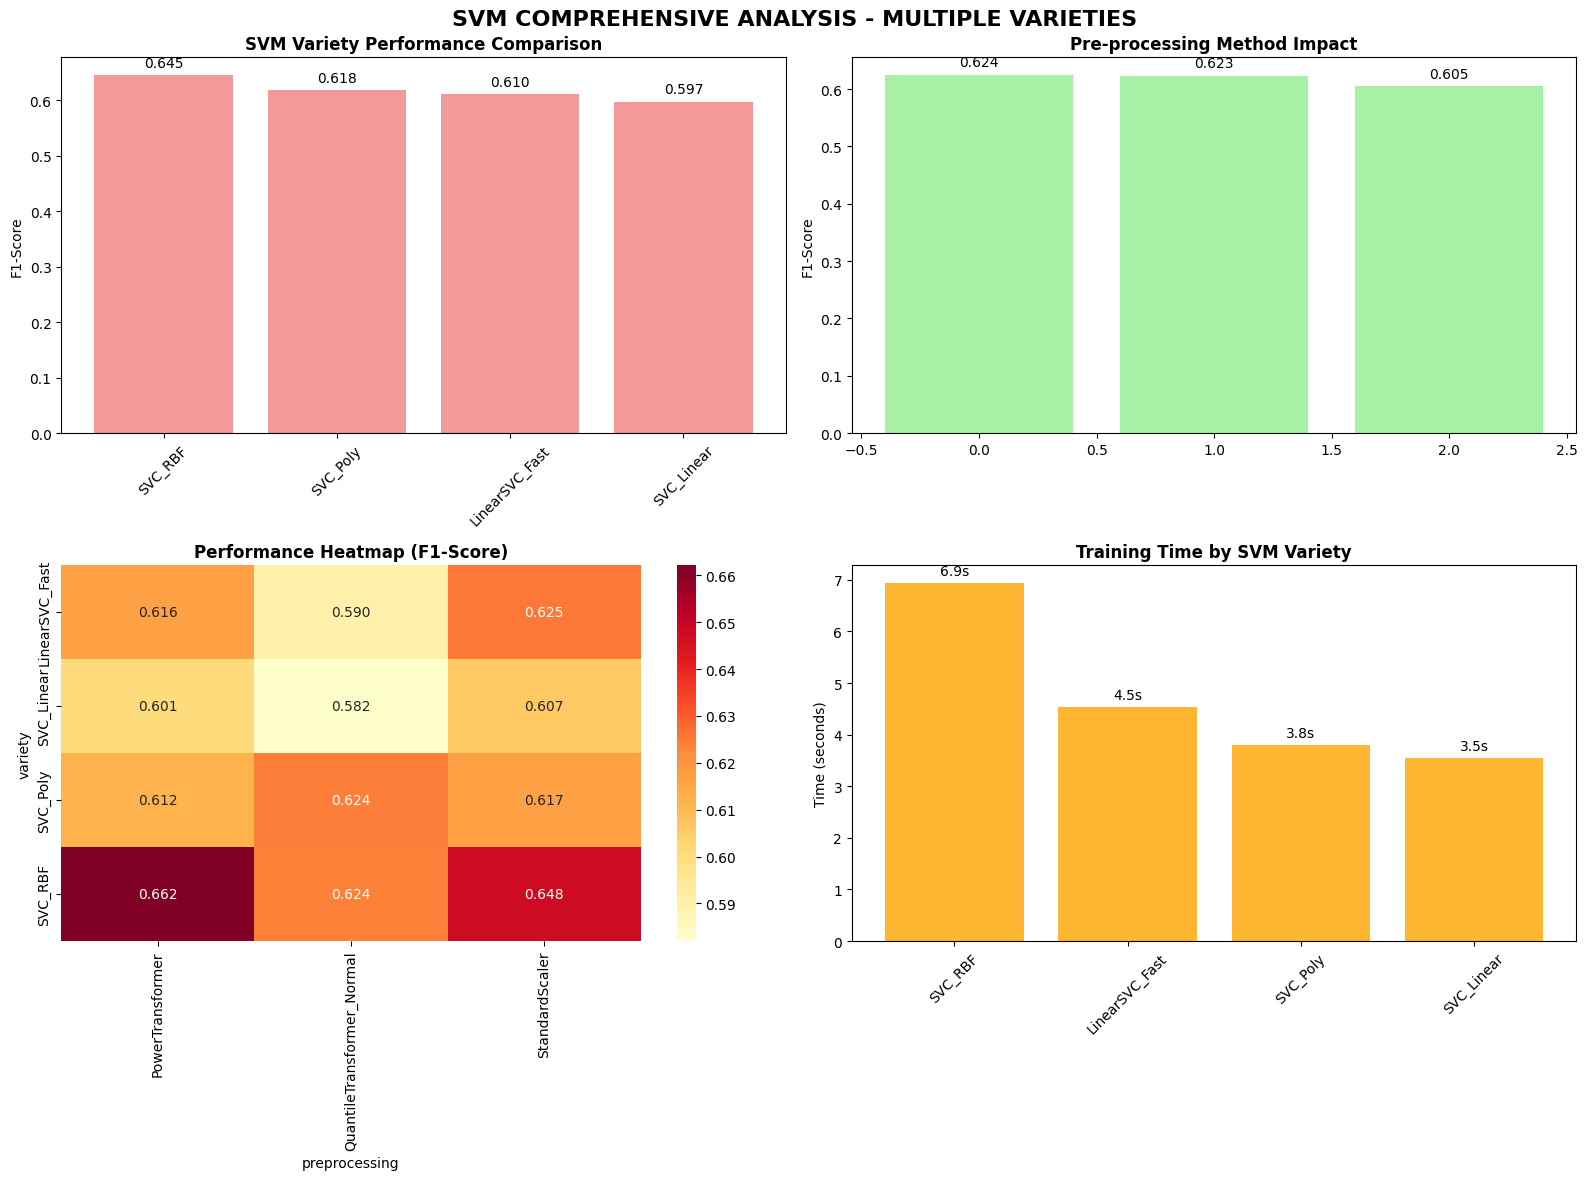

In [8]:
# 4. VISUALIZATIONS

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SVM COMPREHENSIVE ANALYSIS - MULTIPLE VARIETIES', fontsize=16, fontweight='bold')

# 1. Model Variety Performance
variety_f1 = results_df.groupby('variety')['f1'].mean().sort_values(ascending=False)
bars1 = axes[0,0].bar(range(len(variety_f1)), variety_f1.values, color='lightcoral', alpha=0.8)
axes[0,0].set_title('SVM Variety Performance Comparison', fontweight='bold')
axes[0,0].set_ylabel('F1-Score')
axes[0,0].set_xticks(range(len(variety_f1)))
axes[0,0].set_xticklabels(variety_f1.index, rotation=45)
for i, v in enumerate(variety_f1.values):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Pre-processing Impact
preproc_f1 = results_df.groupby('preprocessing')['f1'].mean().sort_values(ascending=False)
bars2 = axes[0,1].bar(range(len(preproc_f1)), preproc_f1.values, color='lightgreen', alpha=0.8)
axes[0,1].set_title('Pre-processing Method Impact', fontweight='bold')
axes[0,1].set_ylabel('F1-Score')
for i, v in enumerate(preproc_f1.values):
    axes[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 3. Performance Heatmap
pivot_data = results_df.pivot(index='variety', columns='preprocessing', values='f1')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1,0])
axes[1,0].set_title('Performance Heatmap (F1-Score)', fontweight='bold')

# 4. Training Time Comparison
time_data = results_df.groupby('variety')['training_time'].mean().sort_values(ascending=False)
bars4 = axes[1,1].bar(range(len(time_data)), time_data.values, color='orange', alpha=0.8)
axes[1,1].set_title('Training Time by SVM Variety', fontweight='bold')
axes[1,1].set_ylabel('Time (seconds)')
axes[1,1].set_xticks(range(len(time_data)))
axes[1,1].set_xticklabels(time_data.index, rotation=45)
for i, v in enumerate(time_data.values):
    axes[1,1].text(i, v + 0.1, f'{v:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [9]:
# 5. COMPREHENSIVE EXPLANATION

print(f"""
COMPARISON :
   • Best Performing: {best_overall['variety']} with {best_overall['preprocessing']}
   • Key Finding: {variety_performance.index[0]} kernel performed best
   • Performance Range: F1-Scores from {results_df['f1'].min():.3f} to {results_df['f1'].max():.3f}
   • Training Time: Significant variation between kernels
""")


COMPARISON :
   • Best Performing: SVC_RBF with PowerTransformer
   • Key Finding: LinearSVC_Fast kernel performed best
   • Performance Range: F1-Scores from 0.582 to 0.662
   • Training Time: Significant variation between kernels

